In [2]:
import kagglehub
import os
from collections import defaultdict
import shutil
import random
from sklearn.model_selection import train_test_split
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torchvision.models as models
from torchvision.models import DenseNet121_Weights
import copy
from tqdm import tqdm
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Subset

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gallo33henrique/chest-x-ray-and-oct-medical-image-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.14G/1.14G [00:11<00:00, 111MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/gallo33henrique/chest-x-ray-and-oct-medical-image-dataset/versions/1


# New Section

In [4]:
base_path = path

def print_dir_tree(start_path, max_depth=3):
    for root, dirs, files in os.walk(start_path):
        depth = root.replace(start_path, "").count(os.sep)
        if depth > max_depth:
            continue
        indent = "│   " * depth + "├── "
        print(f"{indent}{os.path.basename(root)}/")
        for f in files[:5]:
            print(f"{indent}    {f}")

print("Dataset directory structure:\n")
print_dir_tree(base_path)

Dataset directory structure:

├── 1/
│   ├── data/
│   │   ├── train/
│   │   │   ├── NORMAL/
│   │   │   ├──     IM-0660-0001.jpeg
│   │   │   ├──     IM-0488-0001.jpeg
│   │   │   ├──     NORMAL2-IM-0796-0001.jpeg
│   │   │   ├──     NORMAL2-IM-0675-0001.jpeg
│   │   │   ├──     NORMAL2-IM-0825-0001.jpeg
│   │   │   ├── PNEUMONIA/
│   │   │   ├──     person321_bacteria_1486.jpeg
│   │   │   ├──     person1116_virus_1841.jpeg
│   │   │   ├──     person899_virus_1553.jpeg
│   │   │   ├──     person654_bacteria_2546.jpeg
│   │   │   ├──     person881_bacteria_2805.jpeg
│   │   ├── test/
│   │   │   ├── NORMAL/
│   │   │   ├──     IM-0073-0001.jpeg
│   │   │   ├──     NORMAL2-IM-0373-0001.jpeg
│   │   │   ├──     IM-0086-0001.jpeg
│   │   │   ├──     NORMAL2-IM-0027-0001.jpeg
│   │   │   ├──     NORMAL2-IM-0111-0001.jpeg
│   │   │   ├── PNEUMONIA/
│   │   │   ├──     person1_virus_8.jpeg
│   │   │   ├──     person21_virus_53.jpeg
│   │   │   ├──     person82_bacteria_402.jpeg
│   │   │  

In [5]:
data_path = os.path.join(base_path, "data")


In [6]:
train_dir=os.path.join(data_path, "train")
test_dir=os.path.join(data_path, "test")
train_dir,test_dir

('/root/.cache/kagglehub/datasets/gallo33henrique/chest-x-ray-and-oct-medical-image-dataset/versions/1/data/train',
 '/root/.cache/kagglehub/datasets/gallo33henrique/chest-x-ray-and-oct-medical-image-dataset/versions/1/data/test')

In [7]:
train_normal_dir=os.path.join(train_dir, "NORMAL")
train_pneumonia_dir=os.path.join(train_dir,"PNEUMONIA")
train_normal_dir,train_pneumonia_dir

('/root/.cache/kagglehub/datasets/gallo33henrique/chest-x-ray-and-oct-medical-image-dataset/versions/1/data/train/NORMAL',
 '/root/.cache/kagglehub/datasets/gallo33henrique/chest-x-ray-and-oct-medical-image-dataset/versions/1/data/train/PNEUMONIA')

In [8]:
test_normal_dir=os.path.join(test_dir, "NORMAL")
test_pneumonia_dir=os.path.join(test_dir,"PNEUMONIA")
test_normal_dir,test_pneumonia_dir

('/root/.cache/kagglehub/datasets/gallo33henrique/chest-x-ray-and-oct-medical-image-dataset/versions/1/data/test/NORMAL',
 '/root/.cache/kagglehub/datasets/gallo33henrique/chest-x-ray-and-oct-medical-image-dataset/versions/1/data/test/PNEUMONIA')

In [9]:
num_norma_train=len(os.listdir(train_normal_dir))
num_pneumonia_train=len(os.listdir(train_pneumonia_dir))
num_norma_test=len(os.listdir(test_normal_dir))
num_pneumonia_test=len(os.listdir(test_pneumonia_dir))
total_train=num_norma_train+num_pneumonia_train
total_test=num_norma_test+num_pneumonia_test


In [10]:
print("total training normal images:", num_norma_train)
print("total training pneumonia images:", num_pneumonia_train)
print("--")
print("total test normal images:", num_norma_test)
print("total test pneumonia images:", num_pneumonia_test)
print("--")
print("Total training images:", total_train)
print("Total test images:", total_test)

total training normal images: 1349
total training pneumonia images: 3883
--
total test normal images: 234
total test pneumonia images: 390
--
Total training images: 5232
Total test images: 624


## Initialize Per-Class Min/Max Dimensions

### Subtask:
Initialize dictionaries to store `min_width`, `min_height`, `max_width`, and `max_height` for each class (NORMAL, PNEUMONIA) separately.


In [11]:
normal_dims = {
    'min_width': float('inf'),
    'max_width': 0,
    'min_height': float('inf'),
    'max_height': 0
}

pneumonia_dims = {
    'min_width': float('inf'),
    'max_width': 0,
    'min_height': float('inf'),
    'max_height': 0
}

print("Initialized normal_dims:", normal_dims)
print("Initialized pneumonia_dims:", pneumonia_dims)

Initialized normal_dims: {'min_width': inf, 'max_width': 0, 'min_height': inf, 'max_height': 0}
Initialized pneumonia_dims: {'min_width': inf, 'max_width': 0, 'min_height': inf, 'max_height': 0}



Now that the dictionaries are initialized, the next step is to prepare the image directories for iteration. This code block will create a dictionary that maps class labels ('NORMAL', 'PNEUMONIA') to their respective training data directories.



In [12]:
image_dirs = {
    'NORMAL': train_normal_dir,
    'PNEUMONIA': train_pneumonia_dir
}

print("Image directories for processing:", image_dirs)

Image directories for processing: {'NORMAL': '/root/.cache/kagglehub/datasets/gallo33henrique/chest-x-ray-and-oct-medical-image-dataset/versions/1/data/train/NORMAL', 'PNEUMONIA': '/root/.cache/kagglehub/datasets/gallo33henrique/chest-x-ray-and-oct-medical-image-dataset/versions/1/data/train/PNEUMONIA'}


To calculate the minimum and maximum width and height for each image class, it is necessary to iterate through each image in the respective directories. This code block will load images using PIL, extract their dimensions, and update the `normal_dims` and `pneumonia_dims` dictionaries accordingly.



In [13]:
from PIL import Image

all_dims = {
    'NORMAL': normal_dims,
    'PNEUMONIA': pneumonia_dims
}

for label, directory in image_dirs.items():
    print(f"Processing images for class: {label}")
    for filename in os.listdir(directory):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            image_path = os.path.join(directory, filename)
            try:
                with Image.open(image_path) as img:
                    width, height = img.size

                    # Update dimensions for the current class
                    current_dims = all_dims[label]
                    current_dims['min_width'] = min(current_dims['min_width'], width)
                    current_dims['max_width'] = max(current_dims['max_width'], width)
                    current_dims['min_height'] = min(current_dims['min_height'], height)
                    current_dims['max_height'] = max(current_dims['max_height'], height)
            except Exception as e:
                print(f"Could not open image {filename}: {e}")

print("\n--- Final Dimensions ---")
print("NORMAL Image Dimensions:", normal_dims)
print("PNEUMONIA Image Dimensions:", pneumonia_dims)

Processing images for class: NORMAL
Processing images for class: PNEUMONIA

--- Final Dimensions ---
NORMAL Image Dimensions: {'min_width': 912, 'max_width': 2916, 'min_height': 672, 'max_height': 2663}
PNEUMONIA Image Dimensions: {'min_width': 384, 'max_width': 2772, 'min_height': 127, 'max_height': 2304}


## Prepare for Aspect Ratio Calculation

### Subtask:
Ensure the `PIL.Image` library is imported and define a helper function to get image dimensions safely.


In [14]:
def get_image_dimensions(image_path):
    """ Safely gets the dimensions (width, height) of an image. """
    try:
        with Image.open(image_path) as img:
            return img.size
    except Exception as e:
        print(f"Error processing image {image_path}: {e}")
        return None

print("Defined get_image_dimensions function.")

Defined get_image_dimensions function.


In [15]:
normal_aspect_ratios = []
pneumonia_aspect_ratios = []

for label, directory in image_dirs.items():
    print(f"Collecting aspect ratios for class: {label}")
    for filename in os.listdir(directory):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            image_path = os.path.join(directory, filename)
            dimensions = get_image_dimensions(image_path)
            if dimensions:
                width, height = dimensions
                if height != 0:  # Avoid division by zero
                    aspect_ratio = width / height
                    if label == 'NORMAL':
                        normal_aspect_ratios.append(aspect_ratio)
                    elif label == 'PNEUMONIA':
                        pneumonia_aspect_ratios.append(aspect_ratio)

print("Finished collecting aspect ratios.")
print(f"Number of NORMAL aspect ratios collected: {len(normal_aspect_ratios)}")
print(f"Number of PNEUMONIA aspect ratios collected: {len(pneumonia_aspect_ratios)}")

Finished collecting aspect ratios.
Number of NORMAL aspect ratios collected: 1349
Number of PNEUMONIA aspect ratios collected: 3883


In [16]:
import numpy as np

def print_aspect_ratio_stats(label, aspect_ratios):
    if not aspect_ratios:
        print(f"No aspect ratios found for {label}.")
        return

    aspect_ratios_np = np.array(aspect_ratios)
    print(f"\n--- {label} Aspect Ratio Statistics ---")
    print(f"Min: {np.min(aspect_ratios_np):.4f}")
    print(f"Max: {np.max(aspect_ratios_np):.4f}")
    print(f"Mean: {np.mean(aspect_ratios_np):.4f}")
    print(f"Std Dev: {np.std(aspect_ratios_np):.4f}")

print_aspect_ratio_stats('NORMAL', normal_aspect_ratios)
print_aspect_ratio_stats('PNEUMONIA', pneumonia_aspect_ratios)



--- NORMAL Aspect Ratio Statistics ---
Min: 0.8772
Max: 1.8079
Mean: 1.2279
Std Dev: 0.1294

--- PNEUMONIA Aspect Ratio Statistics ---
Min: 0.8354
Max: 3.3788
Mean: 1.5138
Std Dev: 0.2493


### **Check & Drop duplication**

In [17]:
import hashlib
import os
from collections import defaultdict

def calculate_md5(file_path, chunk_size=8192):
    """Calculates the MD5 hash of a file."""
    md5 = hashlib.md5()
    try:
        with open(file_path, 'rb') as f:
            for chunk in iter(lambda: f.read(chunk_size), b''):
                md5.update(chunk)
        return md5.hexdigest()
    except Exception:
        return None

print("MD5 hash calculation utility defined for duplicate checking.")

MD5 hash calculation utility defined for duplicate checking.


Calculating hashes for NORMAL images in /root/.cache/kagglehub/datasets/gallo33henrique/chest-x-ray-and-oct-medical-image-dataset/versions/1/data/train/NORMAL...
Calculating hashes for PNEUMONIA images in /root/.cache/kagglehub/datasets/gallo33henrique/chest-x-ray-and-oct-medical-image-dataset/versions/1/data/train/PNEUMONIA...
Total unique hashes found: 5206
Total duplicate files (not including first instance): 26
Visualizing examples of duplicate image sets...

Displaying duplicate set with hash: dcc3ab0eaf19ff80af9d3d254b340da5


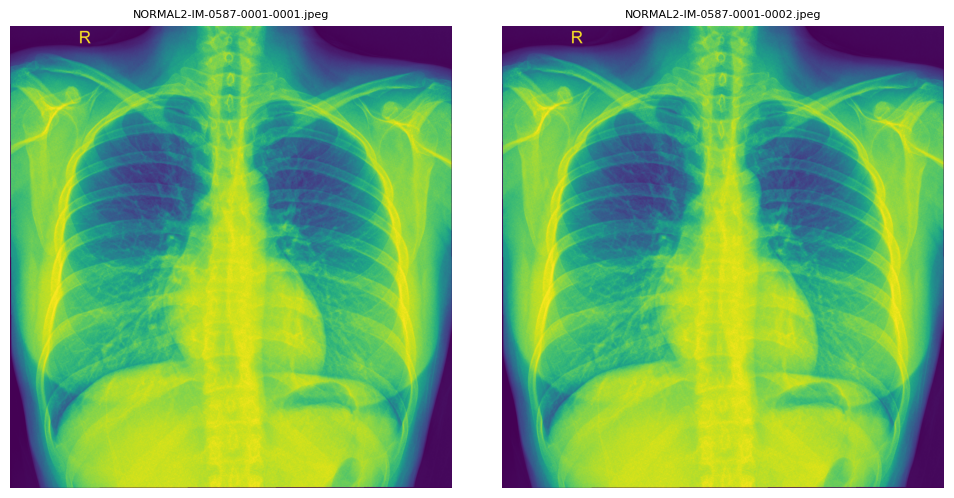


Displaying duplicate set with hash: b6e7fa964af9ca72fb90c64ab20b757b


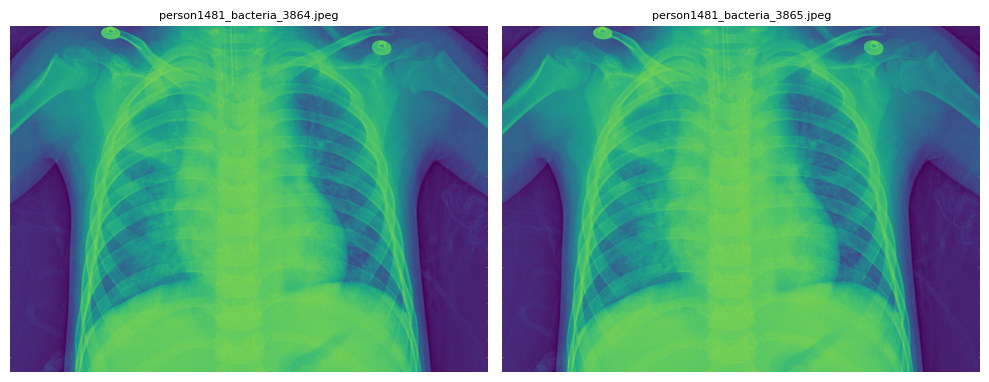


Displaying duplicate set with hash: 9cadd7257f9242e07fe1f974d5bac139


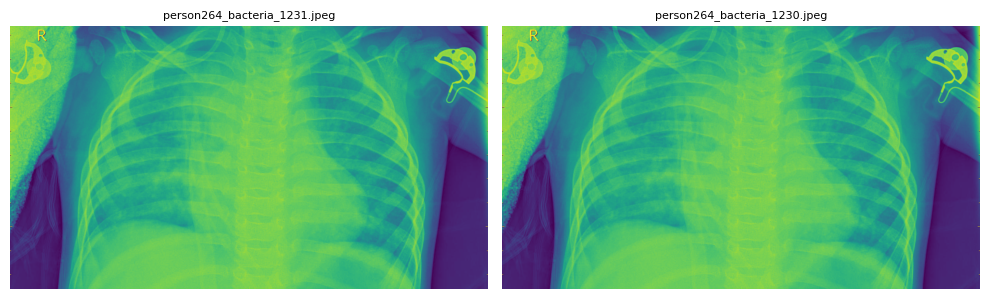

Successfully visualized 3 duplicate image sets.


In [18]:
hashes_and_files = defaultdict(list)

# Assuming `image_dirs` is defined from previous cells
# e.g., image_dirs = {'NORMAL': train_normal_dir, 'PNEUMONIA': train_pneumonia_dir}
# It should contain the directories where images are stored.

for label, directory in image_dirs.items():
    print(f"Calculating hashes for {label} images in {directory}...")
    for filename in os.listdir(directory):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            image_path = os.path.join(directory, filename)
            file_hash = calculate_md5(image_path)
            if file_hash:
                hashes_and_files[file_hash].append(image_path)

print(f"Total unique hashes found: {len(hashes_and_files)}")
duplicate_files_found = sum(len(files) - 1 for files in hashes_and_files.values() if len(files) > 1)
print(f"Total duplicate files (not including first instance): {duplicate_files_found}")

import matplotlib.pyplot as plt
from PIL import Image

# Visualize a few examples of duplicate images
print("Visualizing examples of duplicate image sets...")

num_examples_to_visualize = 3 # Display first 3 duplicate sets
visualized_count = 0

for file_hash, file_list in hashes_and_files.items():
    if len(file_list) > 1 and visualized_count < num_examples_to_visualize:
        print(f"\nDisplaying duplicate set with hash: {file_hash}")
        fig, axes = plt.subplots(1, len(file_list), figsize=(5 * len(file_list), 5))

        # If there's only one image in the list (this case should ideally not happen
        # given the if condition above, but as a safeguard),
        # axes will not be an array, so convert it to handle both cases uniformly.
        if len(file_list) == 1:
            axes = [axes]

        for i, image_path in enumerate(file_list):
            try:
                img = Image.open(image_path)
                axes[i].imshow(img)
                axes[i].set_title(os.path.basename(image_path), fontsize=8)
                axes[i].axis('off')
            except Exception as e:
                print(f"Error loading image {image_path}: {e}")
                axes[i].set_title(f"Error loading {os.path.basename(image_path)}", fontsize=8)
                axes[i].axis('off')

        plt.tight_layout()
        plt.show()
        visualized_count += 1

if visualized_count == 0:
    print("No duplicate image sets were found to visualize.")
else:
    print(f"Successfully visualized {visualized_count} duplicate image sets.")

In [19]:
new_train_dir = '/content/train_data_unique'
os.makedirs(os.path.join(new_train_dir, 'NORMAL'), exist_ok=True)
os.makedirs(os.path.join(new_train_dir, 'PNEUMONIA'), exist_ok=True)

print(f"Created new writable directory: {new_train_dir}")

# Map original labels to subdirectories in new_train_dir
label_to_subdir = {
    os.path.basename(train_normal_dir): os.path.join(new_train_dir, 'NORMAL'),
    os.path.basename(train_pneumonia_dir): os.path.join(new_train_dir, 'PNEUMONIA')
}

files_copied = 0
for file_hash, file_list in hashes_and_files.items():
    # Copy only the first instance of each unique file
    source_path = file_list[0]
    # Determine the original class subdirectory (NORMAL or PNEUMONIA)
    # by checking if the path contains 'NORMAL' or 'PNEUMONIA'
    if 'NORMAL' in source_path and 'train' in source_path:
        dest_dir = label_to_subdir[os.path.basename(train_normal_dir)]
    elif 'PNEUMONIA' in source_path and 'train' in source_path:
        dest_dir = label_to_subdir[os.path.basename(train_pneumonia_dir)]
    else:
        # Handle cases where the path might not fit the expected structure
        # or skip files not in train_dir (e.g., if there were test duplicates, though not expected here)
        continue

    destination_path = os.path.join(dest_dir, os.path.basename(source_path))
    shutil.copy2(source_path, destination_path)
    files_copied += 1

print(f"Copied {files_copied} unique files to {new_train_dir}")

Created new writable directory: /content/train_data_unique
Copied 5206 unique files to /content/train_data_unique


In [20]:
train_dir = new_train_dir
print(f"Updated train_dir to: {train_dir}")

Updated train_dir to: /content/train_data_unique


In [21]:
num_norma_train = len(os.listdir(os.path.join(train_dir, 'NORMAL')))
num_pneumonia_train = len(os.listdir(os.path.join(train_dir, 'PNEUMONIA')))
total_train = num_norma_train + num_pneumonia_train

print("Total training normal images (unique):", num_norma_train)
print("Total training pneumonia images (unique):", num_pneumonia_train)
print("Total training images (unique):", total_train)

Total training normal images (unique): 1348
Total training pneumonia images (unique): 3858
Total training images (unique): 5206


## Preprossing


In [22]:
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224), #  Resize + CenterCrop = smart resize
    transforms.RandomRotation(10),# Data Augmentation
    transforms.RandomHorizontalFlip(), # Data Augmentation
    transforms.ToTensor(),#convert image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Training transformations defined:")
print(train_transforms)

Training transformations defined:
Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [23]:
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Validation/Test transformations defined:")
print(val_test_transforms)

Validation/Test transformations defined:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## Prepare Dataset to Model

In [24]:
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=val_test_transforms)

print(f"Number of images in training dataset: {len(train_dataset)}")
print(f"Number of images in test dataset: {len(test_dataset)}")

Number of images in training dataset: 5206
Number of images in test dataset: 624


In [25]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,num_workers=4,pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size*2, shuffle=False,num_workers=4,pin_memory=True)

print(f"Train DataLoader created with {len(train_loader)} batches of size {batch_size}.")
print(f"Test DataLoader created with {len(test_loader)} batches of size {batch_size}.")

Train DataLoader created with 163 batches of size 32.
Test DataLoader created with 10 batches of size 32.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


# Use  pre-trained ResNet18 model

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")#if GPU is not found use CPU
print(f"Using device: {device}")

#
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False

# Modify the final classification layer for our specific task (binary classification: NORMAL/PNEUMONIA)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2) # 2 output classes (NORMAL, PNEUMONIA)

# Move the model to the device
model = model.to(device)

print("ResNet18 model loaded successfully and moved to device.")
print(model)

Using device: cpu
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 122MB/s]


ResNet18 model loaded successfully and moved to device.
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

# Task
Define the loss function and the optimizer for the ResNet18 model, using `nn.CrossEntropyLoss` as the criterion and `torch.optim.Adam` as the optimizer.

## Define Loss Function and Optimizer

### Subtask:
Specify the criterion for calculating loss (e.g., CrossEntropyLoss for classification) and the optimization algorithm (e.g., Adam or SGD) to update model weights.


**Reasoning**:
The subtask requires defining the loss function using `nn.CrossEntropyLoss` and the optimizer using `torch.optim.Adam` with a specified learning rate. This code block will initialize these components as instructed.



In [27]:
criterion = nn.CrossEntropyLoss()#calculate the error ratio between real value and expected value
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)# minimaze the error ratio and arrive to besto(weight+bais)

print("Loss function (CrossEntropyLoss) defined.")
print("Optimizer (Adam) defined with learning rate 0.001.")

Loss function (CrossEntropyLoss) defined.
Optimizer (Adam) defined with learning rate 0.001.


## Implement Training Loop

### Subtask:
Write the code to iterate through the training data, perform forward and backward passes, and update model parameters using the chosen optimizer.


**Reasoning**:
The subtask requires defining a function `train_epoch` to encapsulate one full pass over the training dataset. This function will handle setting the model to training mode, iterating through batches, moving data to the device, performing forward and backward passes, calculating loss, updating weights, and tracking performance metrics.



In [28]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0  # calculate total loss
    correct_predictions = 0   # calculate total correct prediction
    total_samples = 0  #  total number of images

    for inputs, labels in tqdm(train_loader, desc="Training"): # Shows a progress bar with batches done, remaining, speed, and ETA
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()# gradients جديد لازم اصفر ال batch قبل كل

        outputs = model(inputs) # forward pass
        loss = criterion(outputs, labels) # calculate errors
        loss.backward() # Backpropagation
        optimizer.step() # update weights

        running_loss += loss.item() * inputs.size(0)# collect loss
        _, predicted = torch.max(outputs.data, 1) # calculate prediction and choose the high propapility
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item() # calculate total correct prediction

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    return epoch_loss, epoch_accuracy

print("Function `train_epoch` defined successfully.")

Function `train_epoch` defined successfully.


In [29]:
def validate_epoch(model, val_loader, criterion, device):
    model.eval() # Set model to evaluation mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad(): # Disable gradient calculations during validation
        for inputs, labels in tqdm(val_loader, desc="Validation"): # Shows a progress bar
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    return epoch_loss, epoch_accuracy

print("Function `validate_epoch` defined successfully.")

Function `validate_epoch` defined successfully.


## Implement Main Training Loop

### Subtask:
Implement the main training loop that iterates for a specified number of epochs, calls the `train_epoch` and `validate_epoch` functions, tracks loss and accuracy, and saves the best model based on validation accuracy.

**Reasoning**:
The main training loop is crucial for training the model. It iterates over epochs, calls the `train_epoch` function to train the model, and the `validate_epoch` function to evaluate it. It also stores the best model weights based on validation accuracy and prints the training and validation loss/accuracy for each epoch. This code block implements the full training process.

In [30]:
num_epochs = 3 # Reduce the number of epochs for a quicker training run
print(f"Number of epochs set to: {num_epochs}")

Number of epochs set to: 3


In [31]:

best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    print("-" * 10)

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        print(f"New best model found with accuracy: {best_acc:.4f}")

print("\nTraining complete!")
print(f"Best validation accuracy: {best_acc:.4f}")

# Load best model weights
model.load_state_dict(best_model_wts)

print("Best model weights loaded.")

Epoch 1/3
----------


Training:   0%|          | 0/163 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Validation:   0%|          | 0/10 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system

Train Loss: 0.2937 Acc: 0.8753
Val Loss: 0.4176 Acc: 0.7933
New best model found with accuracy: 0.7933
Epoch 2/3
----------


Validation: 100%|██████████| 10/10 [01:14<00:00,  7.50s/it]


Train Loss: 0.1857 Acc: 0.9257
Val Loss: 0.3396 Acc: 0.8365
New best model found with accuracy: 0.8365
Epoch 3/3
----------


Validation: 100%|██████████| 10/10 [01:14<00:00,  7.49s/it]

Train Loss: 0.1603 Acc: 0.9360
Val Loss: 0.3429 Acc: 0.8349

Training complete!
Best validation accuracy: 0.8365
Best model weights loaded.


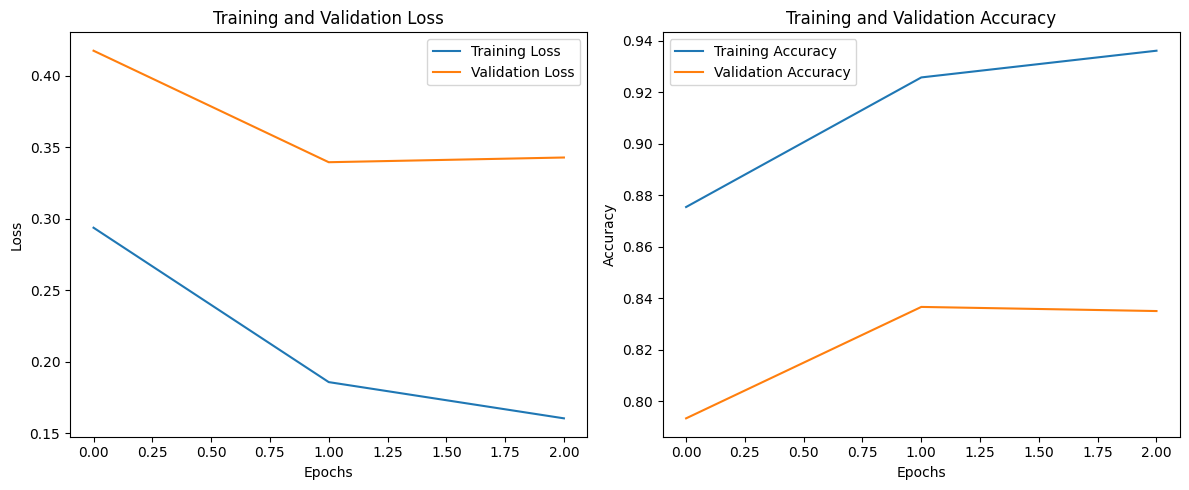

Plots generated for training and validation loss and accuracy.


In [32]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(len(train_losses)), train_losses, label='Training Loss')
plt.plot(range(len(val_losses)), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(range(len(train_accuracies)), train_accuracies, label='Training Accuracy')
plt.plot(range(len(val_accuracies)), val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

print("Plots generated for training and validation loss and accuracy.")

Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Evaluating: 100%|██████████| 10/10 [01:06<00:00,  6.64s/it]



Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.76      0.82      0.79       234
   PNEUMONIA       0.89      0.85      0.87       390

    accuracy                           0.84       624
   macro avg       0.82      0.83      0.83       624
weighted avg       0.84      0.84      0.84       624


Confusion Matrix:
[[191  43]
 [ 59 331]]


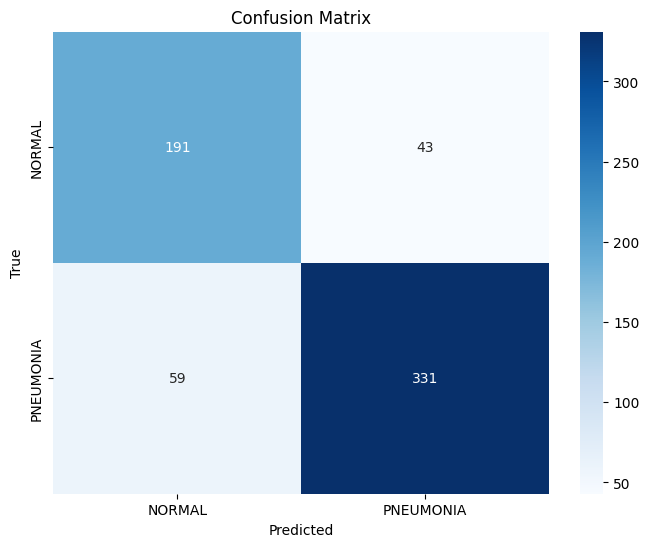

In [33]:
import seaborn as sns

model.eval() # Set model to evaluation mode

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Evaluating"): # Shows a progress bar
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate classification report
class_names = test_dataset.classes # Assuming ImageFolder for test_dataset
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Task
Save the trained PyTorch model's state dictionary to "resnet18_pneumonia_classifier.pth" and then confirm the save and provide instructions on how to load the model.

## Save Trained Model

### Subtask:
Save the trained PyTorch model's state dictionary to a file.


**Reasoning**:
The subtask requires saving the trained model's state dictionary to a file. This code block will use `torch.save` to save the `model.state_dict()` to 'resnet18_pneumonia_classifier.pth' and then print a confirmation message.



In [34]:
torch.save(model.state_dict(), 'resnet18_pneumonia_classifier.pth')
print("Trained model saved successfully as 'resnet18_pneumonia_classifier.pth'")

Trained model saved successfully as 'resnet18_pneumonia_classifier.pth'


## Final Task

### Subtask:
Confirm that the model has been successfully saved and provide instructions on how to load it for future use.


## Summary:

### Q&A
The model has been successfully saved. Instructions on how to load it for future use are provided in the "Insights or Next Steps" section.

### Data Analysis Key Findings
*   The PyTorch model's state dictionary was successfully saved to a file named 'resnet18_pneumonia_classifier.pth'.
*   A confirmation message indicating successful saving was printed, verifying the operation.

### Insights or Next Steps
*   To load the model for future use, first instantiate the same model architecture, then load the saved state dictionary using `model.load_state_dict(torch.load('resnet18_pneumonia_classifier.pth'))`.
*   Consider adding error handling to the saving process to gracefully manage potential issues during file write operations.
